In [110]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns



# Libraries and packages for text (pre-)processing 
import string
import re
import nltk

In [111]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')
# subm = pd.read_csv('./sample_submission.csv')
display(train.shape, train.head())

(3900, 2)

,target,text
0,1,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ..."
1,0,I dont. Can you send it to me. Plus how's mode.
2,0,Aah bless! How's your arm?
3,0,Oh k. . I will come tomorrow
4,0,Yup ok...


#### Capitalization/ Lower case

it would also cause problems with exceptional cases such as the USA or UK, which could be solved by replacing typos, slang, acronyms or informal abbreviations technique.

In [112]:
train["text_clean"] = train["text"].apply(lambda x: x.lower())
test["text_clean"] = test["text"].apply(lambda x: x.lower())
display(train.head())

,target,text,text_clean
0,1,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ...","goal! arsenal 4 (henry, 7 v liverpool 2 henry ..."
1,0,I dont. Can you send it to me. Plus how's mode.,i dont. can you send it to me. plus how's mode.
2,0,Aah bless! How's your arm?,aah bless! how's your arm?
3,0,Oh k. . I will come tomorrow,oh k. . i will come tomorrow
4,0,Yup ok...,yup ok...


### Expand the Contractions

We use the contractions package to expand the contraction in English such as we'll -> we will or we shouldn't've -> we should not have.

In [113]:
import contractions

# Test
test_text = """
            Y'all can't expand contractions I'd think. I'd like to know how I'd done that! 
            We're going to the zoo and I don't think I'll be home for dinner.
            Theyre going to the zoo and she'll be home for dinner.
            We should've do it in here but we shouldn't've eat it
            """
print("Test: ", contractions.fix(test_text))


Test:  
            You all cannot expand contractions I would think. I would like to know how I would done that! 
            We are going to the zoo and I do not think I will be home for dinner.
            They Are going to the zoo and she will be home for dinner.
            We should have do it in here but we should not have eat it
            


In [114]:

train["text_clean"] = train["text_clean"].apply(lambda x: contractions.fix(x))
test["text_clean"] = test["text_clean"].apply(lambda x: contractions.fix(x))

# double check
print(train["text"][67])
print(train["text_clean"][67])
print(train["text"][12])
print(train["text_clean"][12])

But you were together so you should be thinkin about him
but you were together so you should be thinkin about him
FREE for 1st week! No1 Nokia tone 4 ur mobile every week just txt NOKIA to 8077 Get txting and tell ur mates. www.getzed.co.uk POBox 36504 W45WQ 16+ norm150p/tone
free for 1st week! no1 nokia tone 4 you are mobile every week just txt nokia to 8077 get txting and tell you are mates. www.getzed.co.uk pobox 36504 w45wq 16+ norm150p/tone


### Noise Removal

Text data could include various unnecessary characters or punctuation such as URLs, HTML tags, non-ASCII characters, or other special characters (symbols, emojis, and other graphic characters).

In [115]:


def remove_URL(text):
    """
        Remove URLs from a sample string
    """
    return re.sub(r"https?://\S+|www\.\S+", "", text)


def replace_URL(text):
    """
        Replace URLs with a placeholder in a sample string
    """
    return re.sub(r"https?://\S+|www\.\S+", "[URL]", text)

def remove_html(text):
    """
        Remove the html in sample text
    """
    html = re.compile(r"<.*?>|&([a-z0-9]+|#[0-9]{1,6}|#x[0-9a-f]{1,6});")
    return re.sub(html, "", text)



def remove_non_ascii(text):
    """
        Remove non-ASCII characters 
    """
    return re.sub(r'[^\x00-\x7f]',r'', text) # or ''.join([x for x in text if x in string.printable]) 


def replace_USERNAME(text):
    """
        Replace usernames with a placeholder in a sample string
    """

    return re.sub(r"(?<!\w)@\w+", "[USERNAME]", text)


def replace_consecutive_letters(text):
    """
        Replace 3 or more consecutive letters by 2 letter in a sample string
    """
    return re.sub(r'(.)\1{2,}', r'\1\1', text)




In [116]:
# remove urls from the text
# train["text_clean"] = train["text_clean"].apply(lambda x: remove_URL(x))
# test["text_clean"] = test["text_clean"].apply(lambda x: remove_URL(x))

# replace urls with a placeholder
train["text_clean"] = train["text_clean"].apply(lambda x: replace_URL(x))
test["text_clean"] = test["text_clean"].apply(lambda x: replace_URL(x))

train["text_clean"] = train["text_clean"].apply(lambda x: remove_html(x))
test["text_clean"] = test["text_clean"].apply(lambda x: remove_html(x))

train["text_clean"] = train["text_clean"].apply(lambda x: remove_non_ascii(x))
test["text_clean"] = test["text_clean"].apply(lambda x: remove_non_ascii(x))



# replace @USERNAME with [USERNAME]
train["text_clean"] = train["text_clean"].apply(lambda x: replace_USERNAME(x))
test["text_clean"] = test["text_clean"].apply(lambda x: replace_USERNAME(x))


# Replace 3 or more consecutive letters by 2 letter.
train["text_clean"] = train["text_clean"].apply(lambda x: replace_consecutive_letters(x))
test["text_clean"] = test["text_clean"].apply(lambda x: replace_consecutive_letters(x))

# double check
print(train["text"][31])
print(train["text_clean"][31])
print(train["text"][37])
print(train["text_clean"][37])
print(train["text"][62])
print(train["text_clean"][62])

Want 2 get laid tonight? Want real Dogging locations sent direct 2 ur Mob? Join the UK's largest Dogging Network by txting MOAN to 69888Nyt. ec2a. 31p.msg@150p
want 2 get laid tonight? want real dogging locations sent direct 2 you are mob? join the uk's largest dogging network by txting moan to 6988nyt. ec2a. 31p.message@150p
Sorry da:)i was thought of calling you lot of times:)lil busy.i will call you at noon..
sorry da:)i was thought of calling you lot of times:)lil busy.i will call you at noon..
Lol yep did that yesterday. Already got my fireplace. Now its just another icon sitting there for me.
lol yep did that yesterday. already got my fireplace. now its just another icon sitting there for me.


**Contains numbers?**

In [117]:
# Replace numbers with a token (BEST baseline)
train['text_clean'] = train['text_clean'].str.replace(r'\d+', ' <NUM> ', regex=True)
test['text_clean'] = test['text_clean'].str.replace(r'\d+', ' <NUM> ', regex=True)
# Keep a feature
train['has_number'] = train['text_clean'].str.contains(r'\d+', regex=True, na=False).astype(int)
test['has_number'] = test['text_clean'].str.contains(r'\d+', regex=True, na=False).astype(int)
# Count numbers (even better feature)
train['num_count'] = train['text_clean'].str.count(r'\d+')
test['num_count'] = test['text_clean'].str.count(r'\d+')



**Remove special characters:**

The special characters could be symbols, emojis, and other graphic characters.

In [118]:
def remove_special_characters(text):
    """
        Remove special special characters, including symbols, emojis, and other graphic characters
    """
    emoji_pattern = re.compile(
        '['
        u'\U0001F600-\U0001F64F'  # emoticons
        u'\U0001F300-\U0001F5FF'  # symbols & pictographs
        u'\U0001F680-\U0001F6FF'  # transport & map symbols
        u'\U0001F1E0-\U0001F1FF'  # flags (iOS)
        u'\U00002702-\U000027B0'
        u'\U000024C2-\U0001F251'
        ']+',
        flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


# remove non-ascii characters from the text
train["text_clean"] = train["text_clean"].apply(lambda x: remove_special_characters(x))
test["text_clean"] = test["text_clean"].apply(lambda x: remove_special_characters(x))

# double check
print(train["text"][143])
print(train["text_clean"][143])
print(train["text"][189])
print(train["text_clean"][189])


I thk 530 lor. But dunno can get tickets a not. Wat u doing now?
i thk  <NUM>  lor. but do not know can get tickets a not. wat you doing now?
I want to send something that can sell fast.  &lt;#&gt; k is not easy money.
i want to send something that can sell fast.  # k is not easy money.


**Remove punctuations:**

In [119]:
def remove_punct(text):
    """
        Remove the punctuation
    """
#     return re.sub(r'[]!"$%&\'()*+,./:;=#@?[\\^_`{|}~-]+', "", text)
    return text.translate(str.maketrans('', '', string.punctuation))


# remove punctuations from the text
train["text_clean"] = train["text_clean"].apply(lambda x: remove_punct(x))
test["text_clean"] = test["text_clean"].apply(lambda x: remove_punct(x))


# double check
print(train["text"][5])
print(train["text_clean"][5])
# print(train["text"][7597])
# print(train["text_clean"][7597])


He needs to stop going to bed and make with the fucking dealing
he needs to stop going to bed and make with the fucking dealing


**Other Manual Text Cleaning Tasks:**

Other techniques could be considered and manually processed case by case:

- Replace the Unicode character with equivalent ASCII character (instead of removing)
- Replace the entity references with their actual symbols  instead of removing as HTML tags
- Replace the Typos, slang, acronyms or informal abbreviations - depend on different situations or main topics of the NLP such as finance or medical topics.
- List out all the hashtags/ usernames then replace with equivalent words
- Replace the emoticon/ emoji with equivalant word meaning such as ":)" with "smile" 
- Spelling correction


**Replace the Typos, slang, acronyms or informal abbreviations:**

In [120]:
from shap import sample


def other_clean(text):
        """
            Other manual text cleaning techniques
        """
        # Typos, slang and other
        sample_typos_slang = {
                                "w/e": "whatever",
                                "usagov": "usa government",
                                "recentlu": "recently",
                                "ph0tos": "photos",
                                "amirite": "am i right",
                                "exp0sed": "exposed",
                                "<3": "love",
                                "luv": "love",
                                "amageddon": "armageddon",
                                "trfc": "traffic",
                                "16yr": "16 year"
                                }

        # Acronyms
        sample_acronyms =  { 
                            "mh370": "malaysia airlines flight 370",
                            "okwx": "oklahoma city weather",
                            "arwx": "arkansas weather",    
                            "gawx": "georgia weather",  
                            "scwx": "south carolina weather",  
                            "cawx": "california weather",
                            "tnwx": "tennessee weather",
                            "azwx": "arizona weather",  
                            "alwx": "alabama weather",
                            "usnwsgov": "united states national weather service",
                            "2mw": "tomorrow"
                            }

        
        # Some common abbreviations 
        sample_abbr = {
                        "$" : " dollar ",
                        "€" : " euro ",
                        "4ao" : "for adults only",
                        "a.m" : "before midday",
                        "a3" : "anytime anywhere anyplace",
                        "aamof" : "as a matter of fact",
                        "acct" : "account",
                        "adih" : "another day in hell",
                        "afaic" : "as far as i am concerned",
                        "afaict" : "as far as i can tell",
                        "afaik" : "as far as i know",
                        "afair" : "as far as i remember",
                        "afk" : "away from keyboard",
                        "app" : "application",
                        "approx" : "approximately",
                        "apps" : "applications",
                        "asap" : "as soon as possible",
                        "asl" : "age, sex, location",
                        "atk" : "at the keyboard",
                        "ave." : "avenue",
                        "aymm" : "are you my mother",
                        "ayor" : "at your own risk", 
                        "b&b" : "bed and breakfast",
                        "b+b" : "bed and breakfast",
                        "b.c" : "before christ",
                        "b2b" : "business to business",
                        "b2c" : "business to customer",
                        "b4" : "before",
                        "b4n" : "bye for now",
                        "b@u" : "back at you",
                        "bae" : "before anyone else",
                        "bak" : "back at keyboard",
                        "bbbg" : "bye bye be good",
                        "bbc" : "british broadcasting corporation",
                        "bbias" : "be back in a second",
                        "bbl" : "be back later",
                        "bbs" : "be back soon",
                        "be4" : "before",
                        "bfn" : "bye for now",
                        "blvd" : "boulevard",
                        "bout" : "about",
                        "brb" : "be right back",
                        "bros" : "brothers",
                        "brt" : "be right there",
                        "bsaaw" : "big smile and a wink",
                        "btw" : "by the way",
                        "bwl" : "bursting with laughter",
                        "c/o" : "care of",
                        "cet" : "central european time",
                        "cf" : "compare",
                        "cia" : "central intelligence agency",
                        "csl" : "can not stop laughing",
                        "cu" : "see you",
                        "cul8r" : "see you later",
                        "cv" : "curriculum vitae",
                        "cwot" : "complete waste of time",
                        "cya" : "see you",
                        "cyt" : "see you tomorrow",
                        "dae" : "does anyone else",
                        "dbmib" : "do not bother me i am busy",
                        "diy" : "do it yourself",
                        "dm" : "direct message",
                        "dwh" : "during work hours",
                        "e123" : "easy as one two three",
                        "eet" : "eastern european time",
                        "eg" : "example",
                        "embm" : "early morning business meeting",
                        "encl" : "enclosed",
                        "encl." : "enclosed",
                        "etc" : "and so on",
                        "faq" : "frequently asked questions",
                        "fawc" : "for anyone who cares",
                        "fb" : "facebook",
                        "fc" : "fingers crossed",
                        "fig" : "figure",
                        "fimh" : "forever in my heart", 
                        "ft." : "feet",
                        "ft" : "featuring",
                        "ftl" : "for the loss",
                        "ftw" : "for the win",
                        "fwiw" : "for what it is worth",
                        "fyi" : "for your information",
                        "g9" : "genius",
                        "gahoy" : "get a hold of yourself",
                        "gal" : "get a life",
                        "gcse" : "general certificate of secondary education",
                        "gfn" : "gone for now",
                        "gg" : "good game",
                        "gl" : "good luck",
                        "glhf" : "good luck have fun",
                        "gmt" : "greenwich mean time",
                        "gmta" : "great minds think alike",
                        "gn" : "good night",
                        "g.o.a.t" : "greatest of all time",
                        "goat" : "greatest of all time",
                        "goi" : "get over it",
                        "gps" : "global positioning system",
                        "gr8" : "great",
                        "gratz" : "congratulations",
                        "gyal" : "girl",
                        "h&c" : "hot and cold",
                        "hp" : "horsepower",
                        "hr" : "hour",
                        "hrh" : "his royal highness",
                        "ht" : "height",
                        "ibrb" : "i will be right back",
                        "ic" : "i see",
                        "icq" : "i seek you",
                        "icymi" : "in case you missed it",
                        "idc" : "i do not care",
                        "idgadf" : "i do not give a damn fuck",
                        "idgaf" : "i do not give a fuck",
                        "idk" : "i do not know",
                        "ie" : "that is",
                        "i.e" : "that is",
                        "ifyp" : "i feel your pain",
                        "IG" : "instagram",
                        "iirc" : "if i remember correctly",
                        "ilu" : "i love you",
                        "ily" : "i love you",
                        "imho" : "in my humble opinion",
                        "imo" : "in my opinion",
                        "imu" : "i miss you",
                        "iow" : "in other words",
                        "irl" : "in real life",
                        "j4f" : "just for fun",
                        "jic" : "just in case",
                        "jk" : "just kidding",
                        "jsyk" : "just so you know",
                        "l8r" : "later",
                        "lb" : "pound",
                        "lbs" : "pounds",
                        "ldr" : "long distance relationship",
                        "lmao" : "laugh my ass off",
                        "lmfao" : "laugh my fucking ass off",
                        "lol" : "laughing out loud",
                        "ltd" : "limited",
                        "ltns" : "long time no see",
                        "m8" : "mate",
                        "mf" : "motherfucker",
                        "mfs" : "motherfuckers",
                        "mfw" : "my face when",
                        "mofo" : "motherfucker",
                        "mph" : "miles per hour",
                        "mr" : "mister",
                        "mrw" : "my reaction when",
                        "ms" : "miss",
                        "mte" : "my thoughts exactly",
                        "nagi" : "not a good idea",
                        "nbc" : "national broadcasting company",
                        "nbd" : "not big deal",
                        "nfs" : "not for sale",
                        "ngl" : "not going to lie",
                        "nhs" : "national health service",
                        "nrn" : "no reply necessary",
                        "nsfl" : "not safe for life",
                        "nsfw" : "not safe for work",
                        "nth" : "nice to have",
                        "nvr" : "never",
                        "nyc" : "new york city",
                        "oc" : "original content",
                        "og" : "original",
                        "ohp" : "overhead projector",
                        "oic" : "oh i see",
                        "omdb" : "over my dead body",
                        "omg" : "oh my god",
                        "omw" : "on my way",
                        "p.a" : "per annum",
                        "p.m" : "after midday",
                        "pm" : "prime minister",
                        "poc" : "people of color",
                        "pov" : "point of view",
                        "pp" : "pages",
                        "ppl" : "people",
                        "prw" : "parents are watching",
                        "ps" : "postscript",
                        "pt" : "point",
                        "ptb" : "please text back",
                        "pto" : "please turn over",
                        "qpsa" : "what happens", #"que pasa",
                        "ratchet" : "rude",
                        "rbtl" : "read between the lines",
                        "rlrt" : "real life retweet", 
                        "rofl" : "rolling on the floor laughing",
                        "roflol" : "rolling on the floor laughing out loud",
                        "rotflmao" : "rolling on the floor laughing my ass off",
                        "rt" : "retweet",
                        "ruok" : "are you ok",
                        "sfw" : "safe for work",
                        "sk8" : "skate",
                        "smh" : "shake my head",
                        "sq" : "square",
                        "srsly" : "seriously", 
                        "ssdd" : "same stuff different day",
                        "tbh" : "to be honest",
                        "tbs" : "tablespooful",
                        "tbsp" : "tablespooful",
                        "tfw" : "that feeling when",
                        "thks" : "thank you",
                        "tho" : "though",
                        "thx" : "thank you",
                        "tia" : "thanks in advance",
                        "til" : "today i learned",
                        "tl;dr" : "too long i did not read",
                        "tldr" : "too long i did not read",
                        "tmb" : "tweet me back",
                        "tntl" : "trying not to laugh",
                        "ttyl" : "talk to you later",
                        "u" : "you",
                        "u2" : "you too",
                        "u4e" : "yours for ever",
                        "utc" : "coordinated universal time",
                        "w/" : "with",
                        "w/o" : "without",
                        "w8" : "wait",
                        "wassup" : "what is up",
                        "wb" : "welcome back",
                        "wtf" : "what the fuck",
                        "wtg" : "way to go",
                        "wtpa" : "where the party at",
                        "wuf" : "where are you from",
                        "wuzup" : "what is up",
                        "wywh" : "wish you were here",
                        "yd" : "yard",
                        "ygtr" : "you got that right",
                        "ynk" : "you never know",
                        "zzz" : "sleeping bored and tired"
                        }

        # Defining dictionary containing all emojis with their meanings.
        emojis = {':)': 'smile', ':-)': 'smile', ';d': 'wink', ':-E': 'vampire', ':(': 'sad', 
                ':-(': 'sad', ':-<': 'sad', ':P': 'raspberry', ':O': 'surprised',
                ':-@': 'shocked', ':@': 'shocked',':-$': 'confused', ':\\': 'annoyed', 
                ':#': 'mute', ':X': 'mute', ':^)': 'smile', ':-&': 'confused', '$_$': 'greedy',
                '@@': 'eyeroll', ':-!': 'confused', ':-D': 'smile', ':-0': 'yell', 'O.o': 'confused',
                '<(-_-)>': 'robot', 'd[-_-]b': 'dj', ":'-)": 'sadsmile', ';)': 'wink', 
                ';-)': 'wink', 'O:-)': 'angel','O*-)': 'angel','(:-D': 'gossip', '=^.^=': 'cat'}
        
        sample_typos_slang_pattern = re.compile(r'(?<!\w)(' + '|'.join(re.escape(key) for key in sample_typos_slang.keys()) + r')(?!\w)')
        sample_acronyms_pattern = re.compile(r'(?<!\w)(' + '|'.join(re.escape(key) for key in sample_acronyms.keys()) + r')(?!\w)')
        sample_abbr_pattern = re.compile(r'(?<!\w)(' + '|'.join(re.escape(key) for key in sample_abbr.keys()) + r')(?!\w)')
        sample_emojis_pattern = re.compile(r'(' + '|'.join(re.escape(key) for key in emojis.keys()) + r')')

        text = sample_typos_slang_pattern.sub(lambda x: sample_typos_slang[x.group()], text)
        text = sample_acronyms_pattern.sub(lambda x: sample_acronyms[x.group()], text)
        text = sample_abbr_pattern.sub(lambda x: sample_abbr[x.group()], text)
        text = sample_emojis_pattern.sub(lambda x: emojis[x.group()], text)
        
        return text


In [121]:
# Test
test_text = """
            brb with some sample ph0tos I lov u. I need some $ for 2mw. :) <3
            """
print("Test: ", other_clean(test_text))



Test:  
            be right back with some sample photos I lov you. I need some  dollar  for tomorrow. smile love
            


In [122]:
# remove punctuations from the text
train["text_clean"] = train["text_clean"].apply(lambda x: other_clean(x))
test["text_clean"] = test["text_clean"].apply(lambda x: other_clean(x))
# double check
# print(train["text"][1844])
# print(train["text_clean"][1844])
# print(train["text"][4409])
# print(train["text_clean"][4409])

**Spelling Correction**

Spelling correction could also be considered an optional preprocessing task as the social media text data is often are typos or mistyped. However, the spelling correction output should be carefully double-checked with the original text input as it could be a mistake.

In [45]:
from textblob import TextBlob
print("Test: ", TextBlob("sleapy and tehre is no plaxe I'm gioong to.").correct())
print("Test: ", TextBlob("corect me plese.").correct())


Test:  sleepy and there is no place I'm going to.
Test:  correct me please.


In [30]:
train["text_clean"] = train["text_clean"].apply(lambda x: TextBlob(x).correct())
test["text_clean"] = test["text_clean"].apply(lambda x: TextBlob(x).correct())

KeyboardInterrupt: 

**Spelling Correction** with pyspellchecker

In [4]:
from spellchecker import SpellChecker

spell = SpellChecker()
def correct_spellings(text):
    corrected_text = []
    misspelled_words = spell.unknown(text.split())
    for word in text.split():
        if word in misspelled_words:
            corrected_text.append(spell.correction(word))
        else:
            corrected_text.append(word)
    return " ".join(corrected_text)
        
text = "corect me plese"
correct_spellings(text)

'correct me please'

**Create statistics from texts**

In [47]:


def find_hashtags(tweet):
    return " ".join([match.group(0)[1:] for match in re.finditer(r"#\w+", tweet)]) or 'no'

def find_mentions(tweet):
    return " ".join([match.group(0)[1:] for match in re.finditer(r"@\w+", tweet)]) or 'no'

# def find_links(tweet):
#     return " ".join([match.group(0)[:] for match in re.finditer(r"https?://\S+", tweet)]) or 'no'

def find_links(tweet):
    return " ".join([match.group(0)[:] for match in re.finditer(r"https?://\S+|www.\S+", tweet)]) or 'no' 

def process_text(df):
    
    df['hashtags'] = df['text'].apply(lambda x: find_hashtags(x))
    df['mentions'] = df['text'].apply(lambda x: find_mentions(x))
    df['links'] = df['text'].apply(lambda x: find_links(x))
    # df['hashtags'].fillna(value='no', inplace=True)
    # df['mentions'].fillna(value='no', inplace=True)
    
    return df
    
train = process_text(train)
test = process_text(test)



In [48]:
from wordcloud import STOPWORDS

def create_stat(df):
    # Tweet length
    df['text_len'] = df['text'].apply(len)
    # Word count
    df['word_count'] = df["text"].apply(lambda x: len(str(x).split()))
    # Stopword count
    df['stop_word_count'] = df['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))
    # Punctuation count
    df['punctuation_count'] = df['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
    


    # Count of hashtags (#)
    df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))
    # Count of mentions (@)
    df['mention_count'] = df['mentions'].apply(lambda x: len(str(x).split()))
    # Count of links
    df['link_count'] = df['links'].apply(lambda x: len(str(x).split()))
    # Count of uppercase letters
    df['caps_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    # Ratio of uppercase letters
    df['caps_ratio'] = df['caps_count'] / df['text_len']
    return df

train = create_stat(train)
test = create_stat(test)

print(train.shape, test.shape)

(3900, 17) (1672, 15)


In [49]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
train[num_cols].corr()['target'].drop('target').sort_values()

link_count          -0.006302
stop_word_count      0.039574
mention_count        0.040695
punctuation_count    0.136193
caps_ratio           0.168503
word_count           0.300902
caps_count           0.369592
text_len             0.395436
has_number                NaN
num_count                 NaN
hashtag_count             NaN
Name: target, dtype: float64

In [123]:
train = train[~train['text'].isin([':-) :-)', ':) '])]
train[train['text'] == ':-) :-)']

,target,text,text_clean,has_number,num_count


In [124]:
test[test['text_clean'].isna()]

,target,text,text_clean,has_number,num_count


In [125]:
test.iloc[389]

target                                                        0
text          How do friends help us in problems? They give ...
text_clean    how do friends help us in problems they give t...
has_number                                                    0
num_count                                                     0
Name: 389, dtype: object

In [126]:
print(train.shape)
print(test.shape)


(3898, 5)
(1672, 5)


In [127]:
train[train['target'] == 'ham']

,target,text,text_clean,has_number,num_count


In [128]:
train.to_csv('./data/train_clean.csv', index=False)  # index=False prevents writing row numbers
test.to_csv('./data/test_clean.csv', index=False)  # index=False prevents writing row numbers

In [129]:

print(test['target'].unique())
print(test['target'].dtype)
print(test.shape)

[1 0]
int64
(1672, 5)


In [130]:
import pandas as pd

test_clean = pd.read_csv('./data/test_clean.csv')

print(test_clean['target'].unique())
print(test_clean['target'].dtype)
print(test_clean.shape)

['1' '0' 'ham']
object
(1673, 5)


In [131]:
test_clean.iloc[391]

target                                                        0
text          Do you hide anythiing or keeping distance from me
text_clean    do you hide anythiing or keeping distance from me
has_number                                                  0.0
num_count                                                   0.0
Name: 391, dtype: object

In [132]:
with open('./data/test_clean.csv', 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if 'ham' in line:
        print(i, line)

155 0,That's a shame! Maybe cld meet for few hrs tomo?,that is a shame maybe cld meet for few hrs tomo,0,0

285 0,"U need my presnts always bcz U cant mis love. \jeevithathile irulinae neekunna prakasamanu sneham\"" prakasam ennal prabha 'That mns prabha is'LOVE' Got it. Dont mis me....""",you need my presnts always bcz you cannot mis love jeevithathile irulinae neekunna prakasamanu sneham prakasam ennal prabha that mns prabha islove got it do not mis me,0,0

390 ham""",hi wk been ok  on hols now yes on for a bit of a run forgot that i have hairdressers appointment at four so need to get home n shower beforehand does that because prob for you

391 ham,0,0

416 0,is your hamster dead? Hey so tmr i meet you at 1pm orchard mrt? ,is your hamster dead hey so tomorrow i meet you at  NUM prime minister orchard mrt ,0,0

427 0,"Just got part Nottingham - 3 hrs 63miles. Good thing i love my man so much, but only doing 40mph. Hey ho",just got part nottingham   NUM  hrs  NUM miles good thing i lo

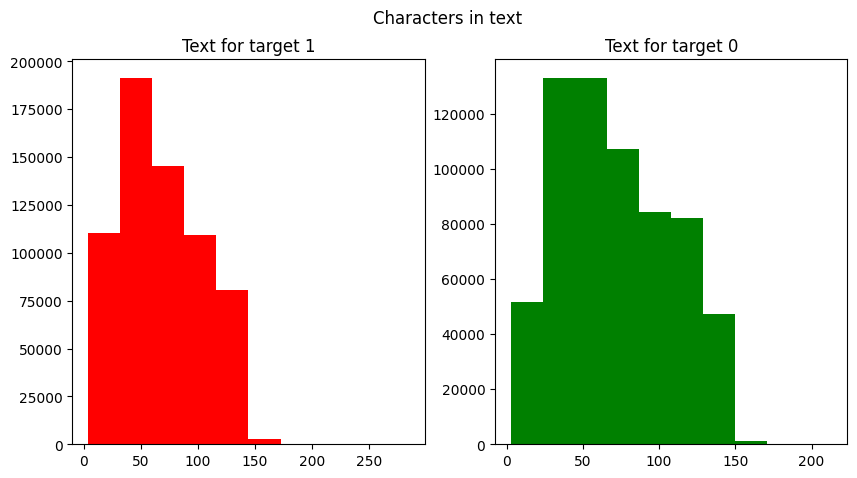